In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# plt.style.use('chalk.mplstyle')

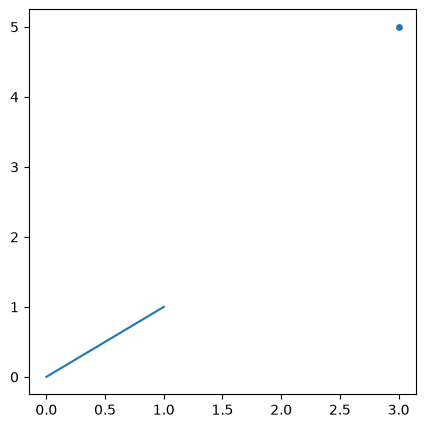

In [3]:
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1])
plt.scatter(3, 5, s=15)
plt.grid(False)
# plt.gca().set_facecolor('green')
plt.show()

In [4]:
from chalk import chalk, ChalkEffect, _CHALK_CYCLE

In [5]:
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20

# green colors: #29635f, #1e5647

/var/folders/d6/lx3ld9gd6kg4j1qq4qkztcq80000gn/T/ipykernel_43601/4257051030.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.linspace(0, 2, 20), np.log10(np.linspace(0, 2, 20)), ls='--', lw=10)
/var/folders/d6/lx3ld9gd6kg4j1qq4qkztcq80000gn/T/ipykernel_43601/4257051030.py:9: RuntimeWarning: divide by zero encountered in divide
  plt.plot(np.linspace(0, 2, 20), 1/(np.linspace(0, 2, 20)), ls='--', lw=10)


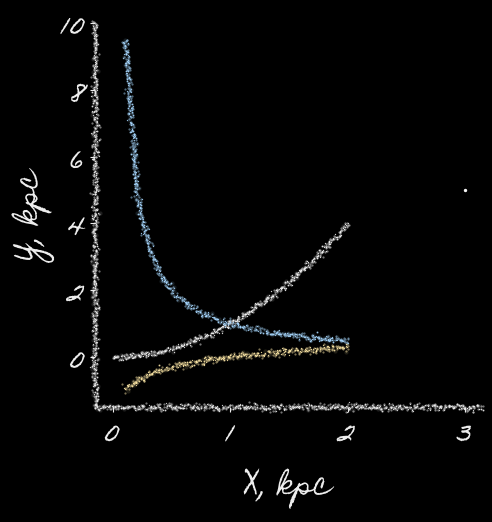

In [6]:
with chalk(sketch=None, board='black', panel='black', 
font='/Users/mouse13/Library/Fonts/HomemadeApple-9zz5.ttf', 
grain=ChalkEffect(spacing=2, spread=1.5, jitter=0.5, 
wander=0.0, grain=2.2, alpha=0.9, passes=3, seed=None, keep_fill=False, 
min_extent=26.0, flat_bg=1.)):
    fig = plt.figure(figsize=(5, 5))
    plt.plot(np.linspace(0, 2, 20), np.linspace(0, 2, 20)**2, ls='--', lw=10)
    plt.plot(np.linspace(0, 2, 20), np.log10(np.linspace(0, 2, 20)), ls='--', lw=10)
    plt.plot(np.linspace(0, 2, 20), 1/(np.linspace(0, 2, 20)), ls='--', lw=10)
    plt.scatter(3, 5, s=2)
    plt.grid(False)
    # plt.gca().set_facecolor('green')
    
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel('X, kpc', fontsize=20)
    plt.ylabel('Y, kpc', fontsize=20)

plt.gca().patch.set_path_effects([])
plt.show()

In [7]:
orbits = np.load('orbit_test.npz.npy')
orbits.shape

(2, 869)

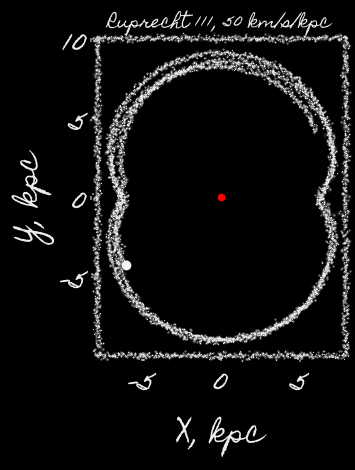

In [18]:
with chalk(sketch=None, board='black', panel='black', 
font='/Users/mouse13/Library/Fonts/HomemadeApple-9zz5.ttf', 
grain=ChalkEffect(spacing=2, spread=1.5, jitter=0.5, 
wander=0.2, grain=2.2, alpha=0.9, passes=3, seed=None, keep_fill=False, 
min_extent=2.0, flat_bg=1.,), ref_linewidth=2.):
    plt.figure()
    plt.plot(orbits[0], orbits[1], lw=10., color=_CHALK_CYCLE[0])
    plt.scatter(orbits[0][-1], orbits[1][-1])
    plt.scatter(0, 0, s=20, c='red')
    plt.grid(False)
    # plt.gca().set_facecolor('green')

    plt.gca().set_aspect('equal')

    plt.xlabel('X, kpc', fontsize=20)
    plt.ylabel('Y, kpc', fontsize=20)

    plt.title('Ruprecht 111, 50 km/s/kpc')
    plt.tight_layout()
    plt.savefig('orbit_test.png', dpi=300)
    plt.show()

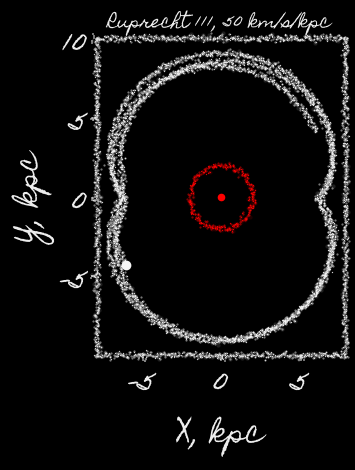

In [34]:
from matplotlib.patches import Circle

with chalk(sketch=None, board='black', panel='black', 
font='/Users/mouse13/Library/Fonts/HomemadeApple-9zz5.ttf', 
grain=ChalkEffect(spacing=2, spread=1.5, jitter=0.5, 
wander=0.2, grain=2.2, alpha=0.9, passes=3, seed=None, keep_fill=False, 
min_extent=2.0, flat_bg=1.,), ref_linewidth=2.):
    plt.figure()
    plt.plot(orbits[0], orbits[1], lw=10., color=_CHALK_CYCLE[0])
    plt.scatter(orbits[0][-1], orbits[1][-1])
    plt.scatter(0, 0, s=20, c='red')
    plt.grid(False)
    circle = Circle((0, 0), 2, fill=False, color='red', lw=2)
    plt.gca().add_patch(circle)
    # plt.gca().set_facecolor('green')

    plt.gca().set_aspect('equal')

    plt.xlabel('X, kpc', fontsize=20)
    plt.ylabel('Y, kpc', fontsize=20)

    plt.title('Ruprecht 111, 50 km/s/kpc')
    plt.tight_layout()
    plt.savefig('orbit_test.png', dpi=300)
    plt.show()

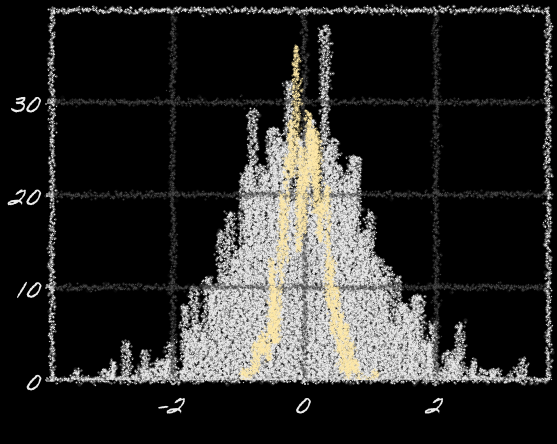

In [35]:
rand = np.random.normal(0, 1, 1000)
rand2 = np.random.normal(0., 0.3, 1000)
plt.hist(rand, bins=100)
plt.hist(rand2, bins=100, histtype='step', lw=10.)
plt.show()

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import re
import pandas as pd

In [20]:
myshpfile = gpd.read_file('../parisExp/idf_gis_osm_roads_free_1.geojson', driver='GeoJSON')

myshpfile = myshpfile.dropna(subset='name')
peri_shp = myshpfile.loc[myshpfile.name.str.startswith("Boulevard Périphérique")]

from shapely.ops import unary_union, linemerge
from shapely.geometry import LineString, MultiLineString

road_lines = peri_shp.geometry.tolist()
merged_lines = linemerge(road_lines)
road_polygon = gpd.GeoDataFrame(geometry=[merged_lines.convex_hull], crs=myshpfile.crs)
# df_tree_inside = df_tree.to_crs('EPSG:4326').clip(road_polygon)

df_street = gpd.read_file('../maps_data/denominations-emprises-voies-actuelles.geojson').clip(road_polygon)

/Users/mouse13/anaconda3/envs/ocenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(
Skipping field arrdt: unsupported OGR type: 5
Skipping field quartier: unsupported OGR type: 5
Skipping field feuille: unsupported OGR type: 5


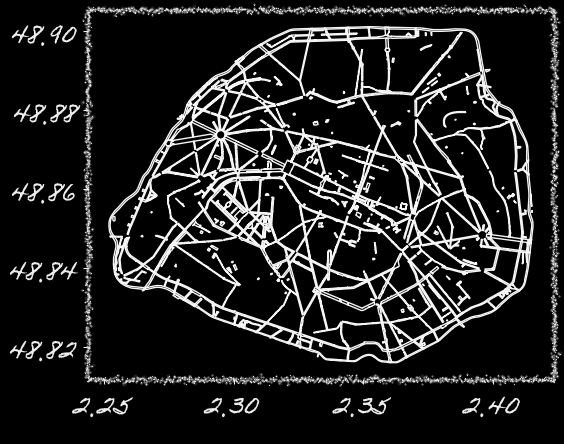

In [36]:
df_street.boundary.loc[df_street.largeur > 20].plot(lw=1.)
plt.gca().grid(False)